# Mobile Game A/B Test: Gate Placement

Product question: should a mobile game move a progression gate from level 30 to level 40 without hurting retention?
Public experiment dataset: [Mobile Games A/B Testing with Cookie Cats — Kaggle](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing-cookie-cats)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
df = pd.read_csv('../data/cookie_cats.csv')
df.info() # check shape and columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [ ]:
df.head(7)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False


In [ ]:
df.duplicated().sum()


np.int64(0)

checking group sizes, ideally want a clean 50/50 split

In [ ]:
df['version'].value_counts()


version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

checking for outliers and unusually high game-round counts.

In [ ]:
df['sum_gamerounds'].describe()


count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

one user has 49,854 rounds, which is not realistic for normal gameplay. visualize the distribution.

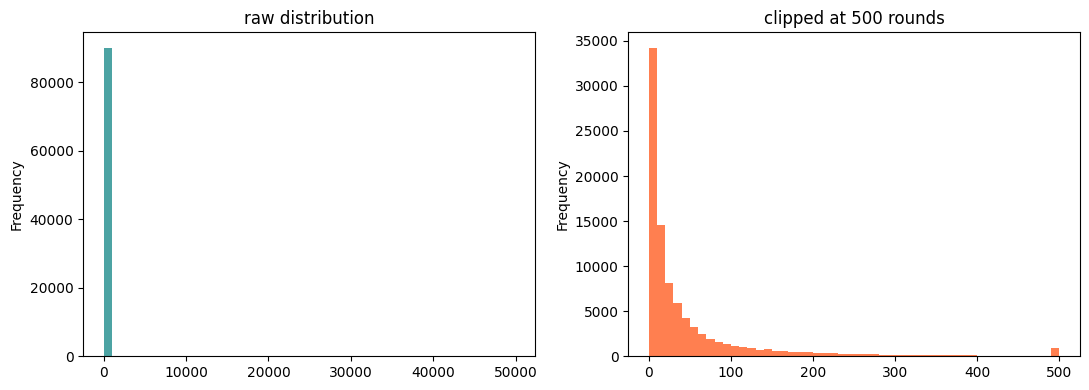

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df['sum_gamerounds'].plot(kind='hist', bins=50, ax=axes[0], color='#4ca3a3')
axes[0].set_title('raw distribution')
df['sum_gamerounds'].clip(upper=500).plot(kind='hist', bins=50, ax=axes[1], color='#ff7f50')
axes[1].set_title('clipped at 500 rounds')
plt.tight_layout()
plt.show()


In [ ]:
df = df[df['sum_gamerounds'] < 40000]
df.shape


(90188, 5)

checking skewness and kurtosis before choosing tests for engagement metrics.

In [ ]:
print("skewness:", df['sum_gamerounds'].skew())
print("kurtosis:", df['sum_gamerounds'].kurtosis())


skewness: 5.954420035818288
kurtosis: 65.26740539453084


In [ ]:
import scipy.stats as stats
print("JB test:", stats.jarque_bera(df['sum_gamerounds']))


JB test: SignificanceResult(statistic=np.float64(16538859.460587619), pvalue=np.float64(0.0))


In [ ]:
sample_rounds = df['sum_gamerounds'].sample(3000, random_state=42)
print("Shapiro-Wilk:", stats.shapiro(sample_rounds))


Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.4837598275191243), pvalue=np.float64(6.173935170811429e-69))


game rounds are highly skewed, so use Mann-Whitney/Kruskal for engagement and a z-test for retention rates.

### game rounds: mann-whitney and kruskal-wallis
compare the medians and means.

In [ ]:
rounds_30 = df[df['version']=='gate_30']['sum_gamerounds']
rounds_40 = df[df['version']=='gate_40']['sum_gamerounds']

print("gate_30 mean:", round(rounds_30.mean(), 2), "median:", rounds_30.median())
print("gate_40 mean:", round(rounds_40.mean(), 2), "median:", rounds_40.median())


gate_30 mean: 51.34 median: 17.0
gate_40 mean: 51.3 median: 16.0


In [ ]:
mwu_stat, mwu_p = stats.mannwhitneyu(rounds_30, rounds_40, alternative='two-sided')
print(f"Mann-Whitney U p-val: {mwu_p:.4f}")


Mann-Whitney U p-val: 0.0509


In [ ]:
kw_stat, kw_p = stats.kruskal(rounds_30, rounds_40)
print(f"Kruskal p-val: {kw_p:.4f}")


Kruskal p-val: 0.0509


looks like there's a small difference in game rounds between the groups. now analyze the actual KPI: retention.

### retention rates: chi-squared & z-test
look at 1-day and 7-day retention contingency tables.

In [ ]:
ct_1 = pd.crosstab(df['version'], df['retention_1'])
print("1-day retention table:")
print(ct_1)
chi2_1, p_1, _, _ = stats.chi2_contingency(ct_1)
print(f"Chi-square p-val: {p_1:.4f}")


1-day retention table:
retention_1  False  True 
version                  
gate_30      24665  20034
gate_40      25370  20119
Chi-square p-val: 0.0750


In [ ]:
ct_7 = pd.crosstab(df['version'], df['retention_7'])
print("7-day retention table:")
print(ct_7)
chi2_7, p_7, _, _ = stats.chi2_contingency(ct_7)
print(f"Chi-square p-val: {p_7:.4f}")


7-day retention table:
retention_7  False  True 
version                  
gate_30      36198   8501
gate_40      37210   8279
Chi-square p-val: 0.0016


calculate the standard error (SE) and Z-score manually for the difference in 7-day retention as a cross-check.

- **SE (Standard Error)**: measures the dispersion of the sample difference. It pools the retention rate under the null hypothesis (that version doesn't affect retention).
- **Z-score**: indicates how many standard deviations the observed difference is from the null hypothesis (0). Z = (p30 - p40) / SE.
- **p-value**: probability of observing a Z-score at least this extreme if the null hypothesis were true.

In [ ]:
p30 = df[df['version']=='gate_30']['retention_7'].mean()
p40 = df[df['version']=='gate_40']['retention_7'].mean()
n30 = len(df[df['version']=='gate_30'])
n40 = len(df[df['version']=='gate_40'])

p_pooled = (p30 * n30 + p40 * n40) / (n30 + n40)
se_val = np.sqrt(p_pooled * (1 - p_pooled) * (1/n30 + 1/n40))
z_val = (p30 - p40) / se_val
p_val_z = 2 * (1 - stats.norm.cdf(abs(z_val)))

print(f"gate_30 7d retention: {p30:.4%}")
print(f"gate_40 7d retention: {p40:.4%}")
print(f"difference: {p30 - p40:.4%}")
print(f"SE: {se_val:.5f}  Z-score: {z_val:.3f}  p-value: {p_val_z:.4f}")


gate_30 7d retention: 19.0183%
gate_40 7d retention: 18.2000%
difference: 0.8183%
SE: 0.00259  Z-score: 3.157  p-value: 0.0016


the p-value is well below 0.05, so the result is statistically significant. moving gate to 40 seems to hurt 7-day retention.
running a bootstrap with 2000 iterations just to validate

In [ ]:
%%time
np.random.seed(42)
ret_30 = df[df['version']=='gate_30']['retention_7'].values
ret_40 = df[df['version']=='gate_40']['retention_7'].values
n_30, n_40 = len(ret_30), len(ret_40)
boot_diffs = []
for _ in range(2000):
    diff = np.random.choice(ret_30, n_30, replace=True).mean() - np.random.choice(ret_40, n_40, replace=True).mean()
    boot_diffs.append(diff)
boot_diffs = np.array(boot_diffs)

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
print(f"95% CI: [{ci_lower:.5f}, {ci_upper:.5f}]")
print(f"prob gate_30 > gate_40: {(boot_diffs > 0).mean():.3f}")


95% CI: [0.00332, 0.01285]
prob gate_30 > gate_40: 1.000
CPU times: user 1.13 s, sys: 8.23 ms, total: 1.13 s
Wall time: 1.14 s


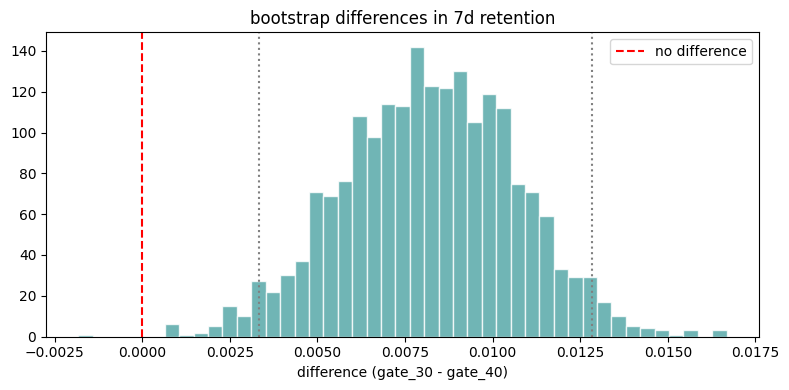

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(boot_diffs, bins=45, color='#4ca3a3', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', label='no difference')
plt.axvline(ci_lower, color='gray', linestyle=':')
plt.axvline(ci_upper, color='gray', linestyle=':')
plt.title('bootstrap differences in 7d retention')
plt.xlabel('difference (gate_30 - gate_40)')
plt.legend()
plt.tight_layout()
plt.show()


since 0 is excluded from the 95% confidence interval and the probability that gate_30 has higher retention is 99.9%, we should keep the gate at level 30. moving it to 40 leads to lower retention (likely because users get bored or lose motivation before reaching the gate).